## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet

## Đọc dữ liệu

In [2]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra dữ liệu

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101469 entries, 0 to 101468
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  101469 non-null  object 
 1   order_purchase_timestamp  101469 non-null  object 
 2   price                     101469 non-null  float64
 3   freight_value             101469 non-null  float64
 4   payment_value             101469 non-null  float64
 5   order_status              101469 non-null  object 
 6   seller_id                 101469 non-null  object 
 7   customer_unique_id        101469 non-null  object 
 8   customer_city             101469 non-null  object 
 9   customer_state            101469 non-null  object 
 10  product_category_name     101469 non-null  object 
 11  Category_VN               101469 non-null  object 
 12  product_id                101469 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.1

,price,freight_value,payment_value
count,101469.000000,101469.000000,101469.000000
mean,120.068787,19.869711,179.993615
std,181.656081,15.480839,274.387174
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.710000
50%,74.990000,16.200000,114.490000
75%,134.900000,21.060000,195.360000
max,6735.000000,409.680000,13664.080000


## Kiểm tra và xử lý dữ liệu thiếu

In [4]:
df.isnull().sum()
df = df.dropna()

In [5]:
## XỬ LÝ THỜI GIAN

In [6]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['date'] = df['order_purchase_timestamp'].dt.date

df_prophet = df.groupby('date')['payment_value'].sum().reset_index()

df_prophet.columns = ['ds','y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

df_prophet = df_prophet.sort_values('ds')


In [7]:
## TRAIN TEST SPLIT (QUAN TRỌNG)

In [8]:
test_days = 30

train = df_prophet.iloc[:-test_days]
test = df_prophet.iloc[-test_days:]


In [9]:
## TRAIN MODEL

In [10]:
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True
)
model.add_country_holidays(country_name='BR')

model.fit(train)

14:09:09 - cmdstanpy - INFO - Chain [1] start processing
14:09:09 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
## PREDICT TRÊN TEST

In [12]:
future = model.make_future_dataframe(periods=test_days)

forecast = model.predict(future)

y_pred = forecast['yhat'][-test_days:].values
y_true = test['y'].values

In [13]:
## EVALUATION

In [14]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("📊 EVALUATION:")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

📊 EVALUATION:
MAE: 11607.09
RMSE: 14190.19


In [15]:
## VISUALIZE (SO SÁNH)

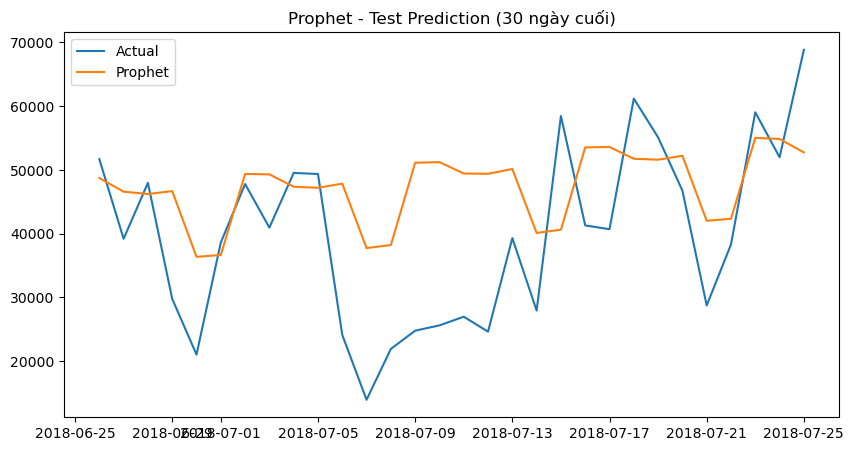

In [25]:
plt.figure(figsize=(10,5))
plt.plot(test['ds'], y_true, label='Actual')
plt.plot(test['ds'], y_pred, label='Prophet')
plt.legend()
plt.title("Prophet - Test Prediction (30 ngày cuối)")
plt.show()


In [26]:
## TRAIN LẠI FULL DATA (QUAN TRỌNG)

In [27]:
final_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True
)

final_model.add_country_holidays(country_name='BR')

final_model.fit(df_prophet)

14:09:22 - cmdstanpy - INFO - Chain [1] start processing
14:09:22 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
## FORECAST TƯƠNG LAI

In [29]:
future_full = final_model.make_future_dataframe(periods=30)

forecast_full = final_model.predict(future_full)

# Xem 30 ngày tới
future_30 = forecast_full[['ds','yhat','yhat_lower','yhat_upper']].tail(30)

print("\n📈 DỰ ĐOÁN 30 NGÀY TỚI:")
print(future_30)


📈 DỰ ĐOÁN 30 NGÀY TỚI:
            ds          yhat    yhat_lower    yhat_upper
576 2018-07-26  50206.664718  34129.368869  65940.459776
577 2018-07-27  50271.590042  34987.982882  66369.432572
578 2018-07-28  39880.039412  24952.334266  55744.332881
579 2018-07-29  40844.224876  25764.827844  57044.429944
580 2018-07-30  52952.726882  37176.658964  67628.871778
581 2018-07-31  52424.331261  36712.252306  68767.824753
582 2018-08-01  50637.661974  33542.905839  65595.822369
583 2018-08-02  49779.165287  34163.608934  65438.251142
584 2018-08-03  49359.770397  34654.162765  64689.497305
585 2018-08-04  38529.663739  21917.115429  54875.181921
586 2018-08-05  39111.287511  23165.700984  55813.303084
587 2018-08-06  50902.063873  34370.562567  66741.026346
588 2018-08-07  50128.008727  34274.530125  65769.535384
589 2018-08-08  48173.180220  31708.685924  62814.294467
590 2018-08-09  47227.522571  31378.683971  64585.919863
591 2018-08-10  46803.434137  30009.581850  61914.689455
592 201

In [30]:
## VISUALIZE FUTURE

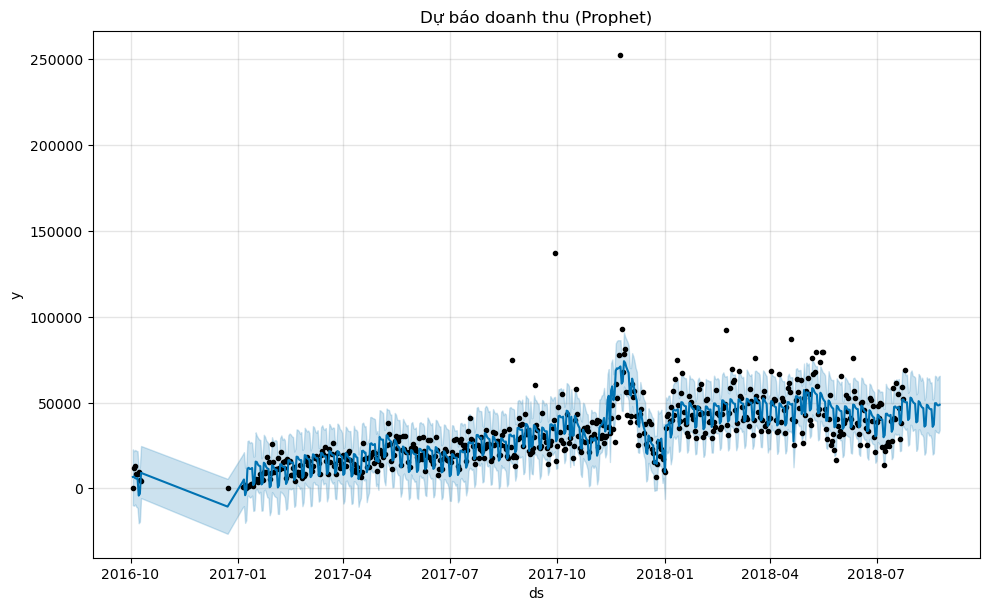

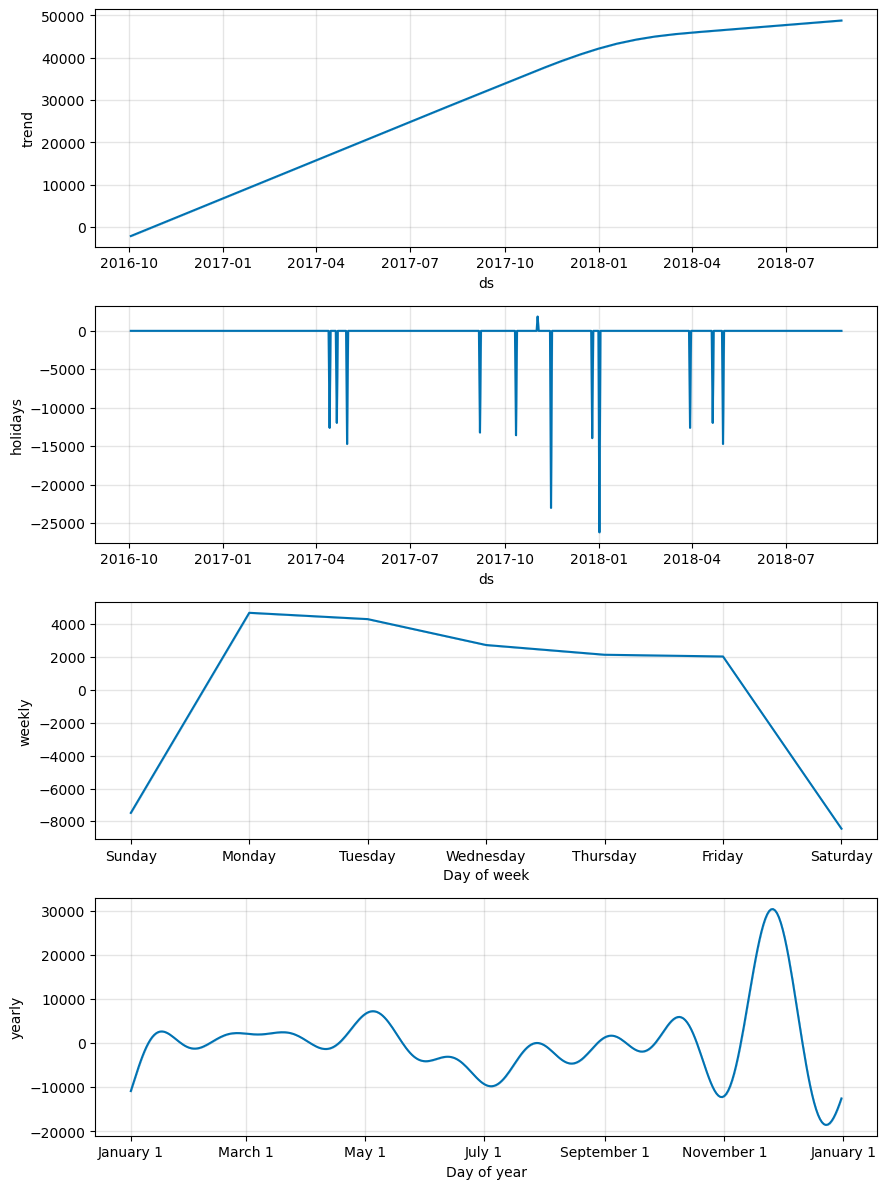

In [31]:
final_model.plot(forecast_full)
plt.title("Dự báo doanh thu (Prophet)")
plt.show()

final_model.plot_components(forecast_full)
plt.show()

### Lưu model vào file bkl

In [32]:
import pickle

with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [33]:
import pickle

pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl","rb"))